[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaxiRuess/DeepLearning_101/blob/main/notebooks/08_JAX/02_Neural_Net_JAX.ipynb)

# Neural Networks from Scratch in JAX

This notebook builds a complete neural network (MLP) trained on MNIST using **only raw JAX** — no Flax, no Equinox, no high-level framework. Everything is pure functions and pytrees.

We'll build the same kind of model you've seen in the PyTorch notebooks, but the JAX way:

| Component | PyTorch | JAX (this notebook) |
|---|---|---|
| Model | `class MLP(nn.Module)` | `init_mlp()` + `mlp_forward()` functions |
| Parameters | `model.parameters()` | Nested dict (pytree) |
| Forward pass | `model(x)` | `mlp_forward(params, x)` |
| Loss | `F.cross_entropy(pred, y)` | `cross_entropy_loss(params, x, y)` |
| Backward | `loss.backward()` | `jax.grad(loss_fn)(params, x, y)` |
| Update | `optimizer.step()` | `jax.tree.map(lambda p, g: p - lr * g, params, grads)` |
| Batching | Manual batch dim | `jax.vmap(forward, in_axes=(None, 0))` |
| Speed | `torch.compile` (opt-in) | `@jax.jit` (default) |

This builds on the [JAX Fundamentals](./01_JAX_Fundamentals.ipynb) notebook. If `jax.grad`, `jax.jit`, and `jax.vmap` aren't familiar yet, start there.

## Setup

In [1]:
import sys, os

if "google.colab" in str(get_ipython()):
    if not os.path.exists("/content/DeepLearning_101"):
        !git clone --depth 1 https://github.com/MaxiRuess/DeepLearning_101.git /content/DeepLearning_101
    os.chdir("/content/DeepLearning_101/notebooks/08_JAX")
    sys.path.insert(0, "/content/DeepLearning_101")
else:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

In [2]:
try:
    import jax
    import jax.numpy as jnp
except ImportError:
    %pip install -q jax jaxlib
    import jax
    import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
import time

print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")

JAX version: 0.9.2
Devices: [CpuDevice(id=0)]


## Load MNIST

We use scikit-learn to avoid a torchvision dependency — this is a pure JAX notebook.

In [3]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Download MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_all, Y_all = mnist.data.astype(np.float32), mnist.target.astype(np.int32)

# Normalize to [0, 1]
X_all = X_all / 255.0

# Train/test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X_all, Y_all, test_size=10000, random_state=42
)

# Convert to JAX arrays
X_train = jnp.array(X_train)
X_test = jnp.array(X_test)
Y_train = jnp.array(Y_train)
Y_test = jnp.array(Y_test)

print(f"Train: X={X_train.shape}, Y={Y_train.shape}")
print(f"Test:  X={X_test.shape}, Y={Y_test.shape}")
print(f"Pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")
print(f"Classes: {np.unique(np.array(Y_train))}")

Train: X=(60000, 784), Y=(60000,)
Test:  X=(10000, 784), Y=(10000,)
Pixel range: [0.0, 1.0]
Classes: [0 1 2 3 4 5 6 7 8 9]


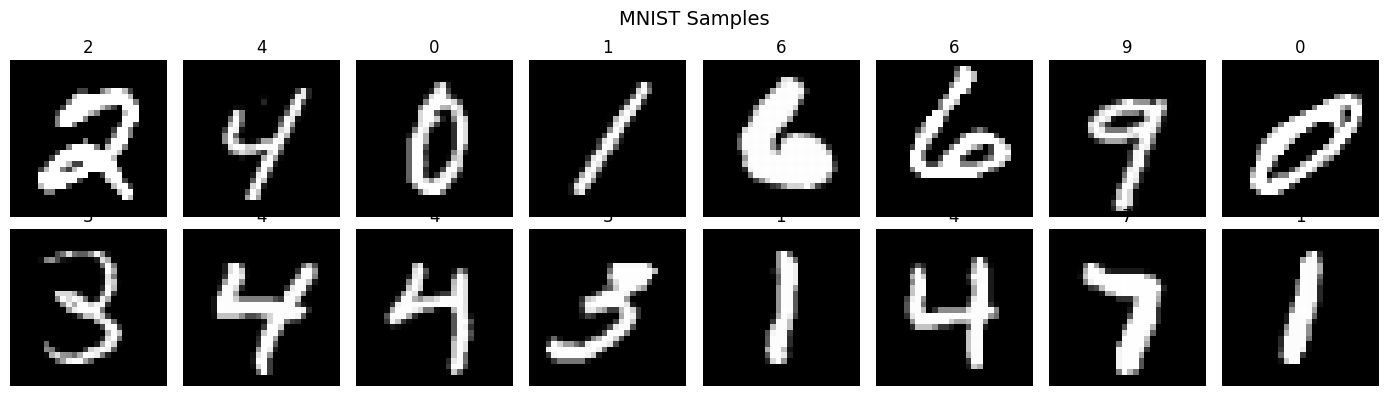

In [4]:
# Visualize some samples
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.array(X_train[i]).reshape(28, 28), cmap='gray')
    ax.set_title(f"{Y_train[i]}", fontsize=12)
    ax.axis('off')
plt.suptitle('MNIST Samples', fontsize=14)
plt.tight_layout()
plt.show()

## The JAX Way: No Classes, Just Functions

In PyTorch, a model is a class:
```python
class MLP(nn.Module):
    def __init__(self):
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        ...
```

In JAX, a model is two functions:
1. `init_mlp(key, sizes)` → returns a **pytree** of parameters
2. `mlp_forward(params, x)` → pure function, no hidden state

Parameters are just nested dicts. No `.parameters()`, no `.state_dict()`, no `.to(device)`.

## Initialize Parameters

In [5]:
def init_mlp(key, layer_sizes):
    """
    Initialize MLP parameters as a list of (weight, bias) dicts.
    Uses He initialization: w ~ N(0, sqrt(2/fan_in)).
    """
    params = []
    for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        key, w_key, b_key = jax.random.split(key, 3)
        params.append({
            'w': jax.random.normal(w_key, (n_out, n_in)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out),
        })
    return params


# Create: 784 → 256 → 128 → 10
key = jax.random.PRNGKey(42)
params = init_mlp(key, [784, 256, 128, 10])

print("Model architecture:")
total_params = 0
for i, layer in enumerate(params):
    n_params = layer['w'].size + layer['b'].size
    total_params += n_params
    print(f"  Layer {i}: {layer['w'].shape[1]} → {layer['w'].shape[0]}  ({n_params:,} params)")
print(f"  Total: {total_params:,} parameters")

Model architecture:
  Layer 0: 784 → 256  (200,960 params)
  Layer 1: 256 → 128  (32,896 params)
  Layer 2: 128 → 10  (1,290 params)
  Total: 235,146 parameters


## Forward Pass

In [6]:
def mlp_forward(params, x):
    """
    Forward pass for a SINGLE input x (shape: [784]).
    ReLU activations on hidden layers, raw logits on output.
    """
    for layer in params[:-1]:
        x = jax.nn.relu(layer['w'] @ x + layer['b'])
    # No activation on final layer — return raw logits
    last = params[-1]
    return last['w'] @ x + last['b']


# Batched version via vmap — no manual batch dimension needed!
batched_forward = jax.vmap(mlp_forward, in_axes=(None, 0))

# Test
logits = batched_forward(params, X_train[:5])
print(f"Input shape:  {X_train[:5].shape}   (5 images, 784 pixels)")
print(f"Output shape: {logits.shape}  (5 images, 10 classes)")
print(f"Predictions:  {jnp.argmax(logits, axis=1)}")
print(f"True labels:  {Y_train[:5]}")

Input shape:  (5, 784)   (5 images, 784 pixels)
Output shape: (5, 10)  (5 images, 10 classes)
Predictions:  [1 1 1 2 0]
True labels:  [2 4 0 1 6]


## Loss Function

Softmax cross-entropy — the standard classification loss:

$L = -\frac{1}{N}\sum_{i=1}^{N} \log\left(\frac{e^{z_{y_i}}}{\sum_j e^{z_j}}\right) = -\frac{1}{N}\sum_{i=1}^{N} \left(z_{y_i} - \log\sum_j e^{z_j}\right)$

We use the numerically stable `log_softmax` formulation.

In [7]:
def cross_entropy_loss(params, X_batch, Y_batch):
    """
    Softmax cross-entropy loss over a batch.
    X_batch: (batch, 784), Y_batch: (batch,) integer labels.
    """
    logits = batched_forward(params, X_batch)            # (batch, 10)
    log_probs = jax.nn.log_softmax(logits, axis=-1)     # numerically stable
    # Select log-prob of the correct class for each example
    loss = -jnp.mean(log_probs[jnp.arange(len(Y_batch)), Y_batch])
    return loss


def compute_accuracy(params, X, Y):
    """Compute classification accuracy."""
    logits = batched_forward(params, X)
    preds = jnp.argmax(logits, axis=1)
    return jnp.mean(preds == Y)


# Test
loss = cross_entropy_loss(params, X_train[:100], Y_train[:100])
acc = compute_accuracy(params, X_train[:100], Y_train[:100])
print(f"Initial loss (random weights): {loss:.4f}")
print(f"Initial accuracy: {acc:.2%}  (expect ~10% for random 10-class)")

Initial loss (random weights): 2.3739
Initial accuracy: 12.00%  (expect ~10% for random 10-class)


## Training Step

`@jax.jit` compiles the entire training step — forward, backward, and parameter update — into a single optimized XLA program.

In [8]:
@jax.jit
def train_step(params, X_batch, Y_batch, lr):
    """
    One training step: forward + backward + SGD update.
    Returns new params and the loss value.
    """
    loss, grads = jax.value_and_grad(cross_entropy_loss)(params, X_batch, Y_batch)
    # SGD: params = params - lr * grads (applied to entire pytree)
    params = jax.tree.map(lambda p, g: p - lr * g, params, grads)
    return params, loss


# Warmup (trigger JIT compilation)
params_test, loss_test = train_step(params, X_train[:32], Y_train[:32], 0.01)
print(f"Training step works! Loss: {loss_test:.4f}")

Training step works! Loss: 2.4087


## Mini-Batch Training Loop

In [9]:
def train(params, X_train, Y_train, X_test, Y_test,
          epochs=5, batch_size=128, lr=0.01):
    """Full training loop with mini-batches."""
    n_train = len(X_train)
    n_batches = n_train // batch_size
    history = {'train_loss': [], 'train_acc': [], 'test_acc': [], 'epoch_time': []}

    for epoch in range(epochs):
        epoch_start = time.perf_counter()

        # Shuffle training data
        key = jax.random.PRNGKey(epoch)
        perm = jax.random.permutation(key, n_train)
        X_shuffled = X_train[perm]
        Y_shuffled = Y_train[perm]

        # Mini-batch training
        epoch_loss = 0.0
        for i in range(n_batches):
            start = i * batch_size
            X_batch = X_shuffled[start:start + batch_size]
            Y_batch = Y_shuffled[start:start + batch_size]
            params, loss = train_step(params, X_batch, Y_batch, lr)
            epoch_loss += float(loss)

        # Evaluate
        avg_loss = epoch_loss / n_batches
        train_acc = float(compute_accuracy(params, X_train[:5000], Y_train[:5000]))
        test_acc = float(compute_accuracy(params, X_test, Y_test))
        epoch_time = time.perf_counter() - epoch_start

        history['train_loss'].append(avg_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['epoch_time'].append(epoch_time)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | "
              f"Train acc: {train_acc:.2%} | Test acc: {test_acc:.2%} | "
              f"Time: {epoch_time:.1f}s")

    return params, history

In [10]:
# Train!
key = jax.random.PRNGKey(42)
params = init_mlp(key, [784, 256, 128, 10])

print("Training MLP on MNIST (784 → 256 → 128 → 10)")
print("=" * 60)

params, history = train(
    params, X_train, Y_train, X_test, Y_test,
    epochs=10, batch_size=128, lr=0.01
)

Training MLP on MNIST (784 → 256 → 128 → 10)
Epoch 1/10 | Loss: 1.0048 | Train acc: 88.10% | Test acc: 86.89% | Time: 1.4s
Epoch 2/10 | Loss: 0.4291 | Train acc: 90.78% | Test acc: 89.58% | Time: 0.4s
Epoch 3/10 | Loss: 0.3466 | Train acc: 91.96% | Test acc: 90.95% | Time: 0.4s
Epoch 4/10 | Loss: 0.3069 | Train acc: 92.68% | Test acc: 91.80% | Time: 0.4s
Epoch 5/10 | Loss: 0.2807 | Train acc: 93.30% | Test acc: 92.21% | Time: 0.4s
Epoch 6/10 | Loss: 0.2612 | Train acc: 93.86% | Test acc: 92.64% | Time: 0.4s
Epoch 7/10 | Loss: 0.2452 | Train acc: 94.26% | Test acc: 93.06% | Time: 0.4s
Epoch 8/10 | Loss: 0.2317 | Train acc: 94.34% | Test acc: 93.35% | Time: 0.4s
Epoch 9/10 | Loss: 0.2194 | Train acc: 94.66% | Test acc: 93.68% | Time: 0.4s
Epoch 10/10 | Loss: 0.2089 | Train acc: 95.08% | Test acc: 93.75% | Time: 0.4s


## Results

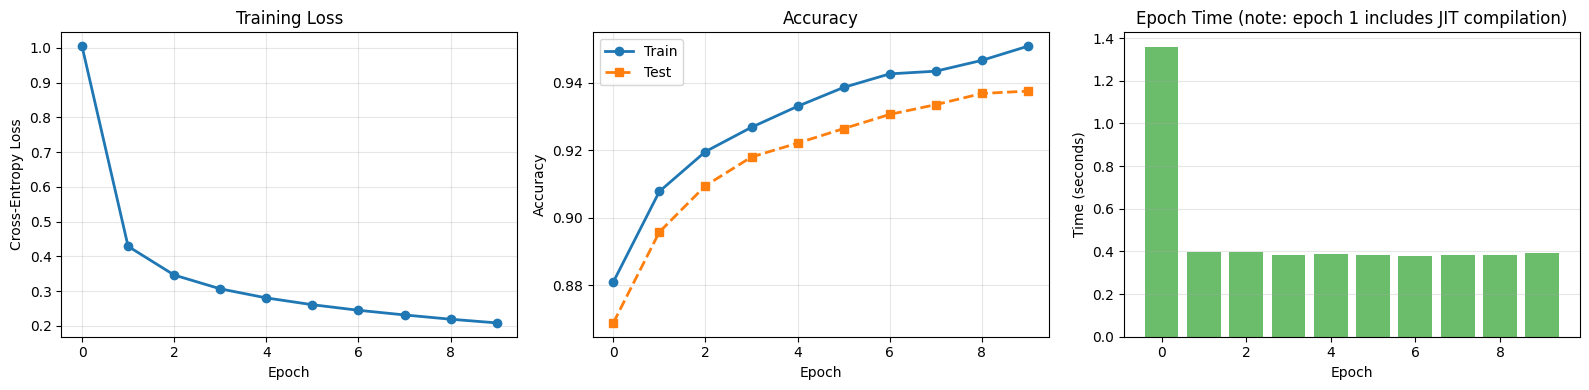

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curve
ax = axes[0]
ax.plot(history['train_loss'], 'o-', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Training Loss')
ax.grid(True, alpha=0.3)

# Accuracy curves
ax = axes[1]
ax.plot(history['train_acc'], 'o-', label='Train', linewidth=2)
ax.plot(history['test_acc'], 's--', label='Test', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# Epoch times
ax = axes[2]
ax.bar(range(len(history['epoch_time'])), history['epoch_time'], color='tab:green', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Time (seconds)')
ax.set_title('Epoch Time (note: epoch 1 includes JIT compilation)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

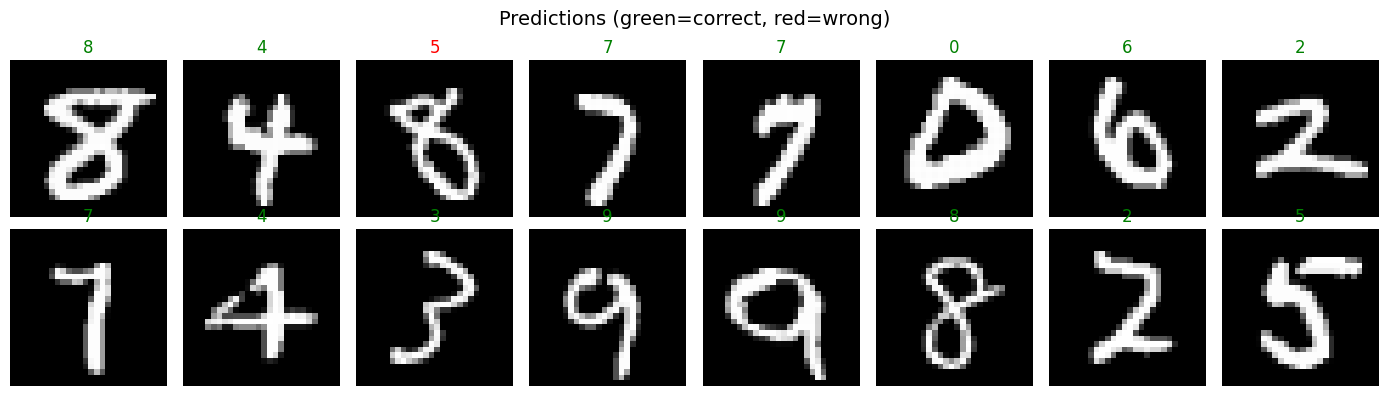

In [12]:
# Sample predictions
test_logits = batched_forward(params, X_test[:32])
test_preds = jnp.argmax(test_logits, axis=1)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.array(X_test[i]).reshape(28, 28), cmap='gray')
    pred = int(test_preds[i])
    true = int(Y_test[i])
    color = 'green' if pred == true else 'red'
    ax.set_title(f"{pred}", fontsize=12, color=color)
    ax.axis('off')
plt.suptitle('Predictions (green=correct, red=wrong)', fontsize=14)
plt.tight_layout()
plt.show()

## PyTorch vs JAX: Side-by-Side

The same MLP in both frameworks:

```python
# ======== PyTorch ========                    # ======== JAX ========

# Model definition                              # Model definition
class MLP(nn.Module):                           def init_mlp(key, sizes):
    def __init__(self):                             params = []
        self.fc1 = nn.Linear(784, 256)              for n_in, n_out in zip(...):
        self.fc2 = nn.Linear(256, 128)                  params.append({'w': ..., 'b': ...})
        self.fc3 = nn.Linear(128, 10)               return params
    def forward(self, x):                       
        x = F.relu(self.fc1(x))                 def mlp_forward(params, x):
        x = F.relu(self.fc2(x))                     for layer in params[:-1]:
        return self.fc3(x)                              x = relu(layer['w'] @ x + layer['b'])
                                                    return params[-1]['w'] @ x + params[-1]['b']

# Training step                                 # Training step
model = MLP().to(device)                        params = init_mlp(key, [784, 256, 128, 10])
optimizer = Adam(model.parameters())            
                                                @jax.jit
for x, y in dataloader:                         def train_step(params, x, y, lr):
    pred = model(x)                                 loss, grads = value_and_grad(loss_fn)(params, x, y)
    loss = F.cross_entropy(pred, y)                 params = tree.map(lambda p, g: p - lr*g,
    loss.backward()                                                   params, grads)
    optimizer.step()                                return params, loss
    optimizer.zero_grad()
```

| | PyTorch | JAX |
|---|---|---|
| Lines of code | ~25 | ~25 |
| State lives in | `model` object | `params` dict (passed explicitly) |
| Optimizer | `Adam` object with internal state | Manual SGD (or use Optax) |
| Compilation | Optional (`torch.compile`) | Default (`@jax.jit`) |
| Batching | Built into `nn.Linear` | `jax.vmap` wraps single-example fn |
| GPU transfer | `model.to(device)`, `x.to(device)` | Automatic (arrays go to default device) |

## What to Notice

1. **No classes anywhere.** The entire model is two functions (`init_mlp` + `mlp_forward`) and a dict of arrays. This feels strange coming from PyTorch but is standard JAX.

2. **`vmap` makes batching trivial.** We wrote `mlp_forward` for a single 784-dim vector. `jax.vmap` created the batched version automatically. In PyTorch, `nn.Linear` has batching built in — but if you write a custom op, you handle batching yourself.

3. **Epoch 1 is slow, rest are fast.** The first call to `train_step` triggers XLA compilation. After that, the compiled version is cached and subsequent epochs are much faster.

4. **No `.backward()`, no `.zero_grad()`.** `jax.value_and_grad` returns both the loss and gradients in one call. No accumulation, no zeroing — gradients are just return values.

5. **SGD is one line.** `jax.tree.map(lambda p, g: p - lr * g, params, grads)` applies SGD to the entire parameter tree. For Adam or other optimizers, use [Optax](https://optax.readthedocs.io/).

6. **>95% accuracy with a simple MLP.** Same ballpark as the PyTorch MNIST notebooks in this repo — the framework doesn't matter for model quality, only for how you express the computation.

## Resources

- [Flax](https://flax.readthedocs.io/) — Google's neural network library for JAX (NNX API is PyTorch-like)
- [Equinox](https://docs.kidger.site/equinox/) — PyTorch-style classes on JAX (most Pythonic option)
- [Optax](https://optax.readthedocs.io/) — Gradient processing and optimizers for JAX (Adam, AdamW, schedules)
- [JAX Neural Network Tutorial](https://jax.readthedocs.io/en/latest/notebooks/neural_network_with_tfds.html) — Official JAX tutorial